In [1]:
import keras
import keras_hub
import numpy as np

In [ ]:
# load pre-trained image segmentation model
model = keras_hub.models.DeepLabV3ImageSegmenter.from_preset("deeplab_v3_plus_resnet50_pascalvoc")

In [3]:
# preprocess images
preprocessor = keras_hub.models.DeepLabV3ImageSegmenterPreprocessor.from_preset("deeplab_v3_plus_resnet50_pascalvoc")

In [4]:
# load sample image
orig_image = keras.utils.load_img("sample.jpg")

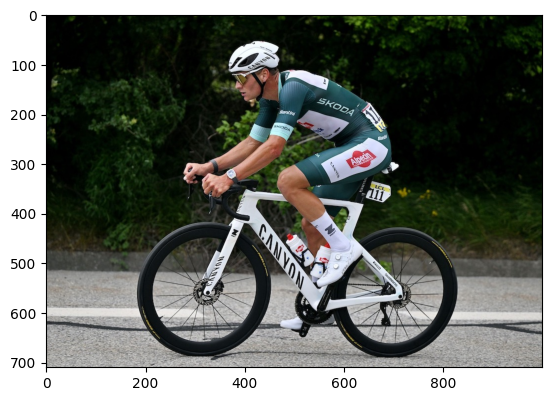

In [5]:
import matplotlib.pyplot as plt
plt.imshow(orig_image)

In [6]:
# run segmentation model
output = model.predict(np.expand_dims(preprocessor(orig_image), axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


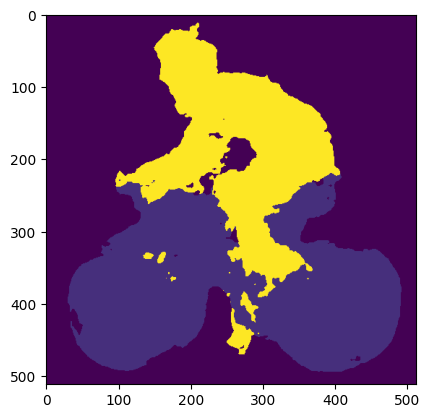

In [7]:
# extract segmentation mask
image_mask = np.argmax(output[0], axis=-1)
plt.imshow(image_mask)

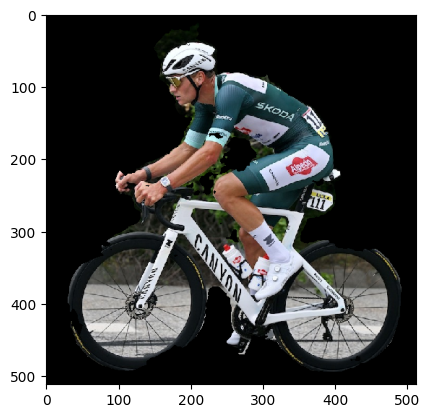

In [8]:
# replace background in original image with black
processed_image = preprocessor(orig_image).numpy()

for i in range(image_mask.shape[0]):
  for j in range(image_mask.shape[1]):
    if image_mask[i][j] == 0:
      processed_image[i][j] = [0, 0, 0]

plt.imshow(processed_image)

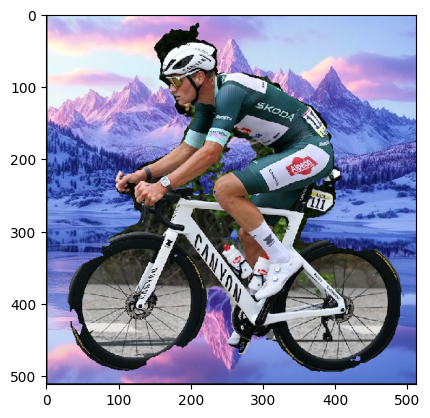

In [9]:
# replace background in original image with new background

background = keras.utils.load_img("bg.png")
background = preprocessor(background).numpy()

processed_image = preprocessor(orig_image).numpy()

for i in range(image_mask.shape[0]):
  for j in range(image_mask.shape[1]):
    if image_mask[i][j] == 0:
      processed_image[i][j] = background[i][j]

plt.imshow(processed_image)